using mps
tensor([19, 29,  0, 11,  1, 86, 90, 28, 23, 31, 39, 96, 82, 17, 71, 39,  8, 97,
        80, 71, 74, 59, 70, 87, 59, 84, 64, 52, 42, 64,  8, 17, 47, 65, 21, 22,
        81, 11, 24, 84, 78, 45, 49, 97, 56, 76, 11, 90, 89, 78, 73, 14, 87,  9,
        71,  6, 47, 20, 98, 47, 36, 55, 72, 43, 51, 35, 83, 33, 27, 53, 92, 50,
        15, 89, 36, 18, 89, 46, 33, 42, 39, 64, 75, 38, 23, 42, 66, 77, 49, 18,
        46, 15, 35, 69, 95, 83, 75, 99, 73, 93, 55, 39,  4, 97, 61, 93, 51, 69,
        56, 84, 59, 64, 94,  4, 11, 33, 68, 38, 20, 33, 34, 32, 46, 53, 88, 67,
        70, 64, 53, 64,  8, 96, 87, 30, 20, 30, 66, 19, 76, 87, 52, 62, 35, 63,
        40,  4, 99, 63, 74, 53, 26, 95, 48, 27, 33, 29, 39, 79, 32, 46, 64, 28,
        85, 32, 82, 78, 39, 54, 28, 66, 65, 72, 21, 64, 62, 72,  0, 44,  7, 12,
        19, 11, 31, 61, 79, 45, 81, 79, 98, 43, 46, 67, 80, 68, 74, 48, 81, 94,
        86, 69, 39, 73,  2, 46, 49, 63, 43, 14, 49, 68, 65, 41, 37, 45, 36, 21,
        77, 37, 39,  8,  9, 62

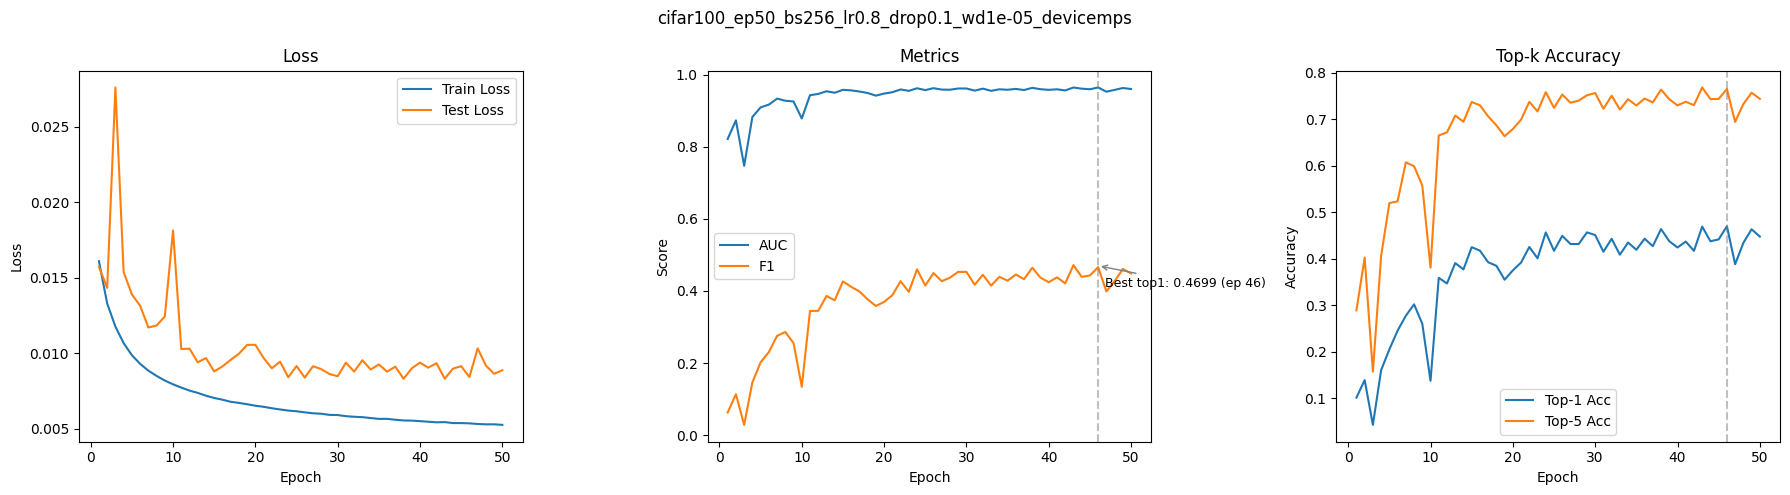

In [1]:
import json
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# hyperparameters
BATCH_SIZE = 256
EPOCHS = 50
LR = 8e-1
WD = 1e-5
INPUT_CHANN = 3
INPUT_DIM = 32
OUTPUT_CLSS = 100
DROPOUT = 0.1
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RUN_ID = f"cifar100_ep{EPOCHS}_bs{BATCH_SIZE}_lr{LR}_drop{DROPOUT}_wd{WD}_device{DEVICE}"
print('using', DEVICE)

training_data = datasets.CIFAR100(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR100(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(next(iter(train_dataloader))[1])

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(INPUT_CHANN, 64, 3, padding = 'same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(DROPOUT),

            nn.Conv2d(64, 64, 3, padding = 'same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(DROPOUT),

            nn.Conv2d(64, 64, 3, padding = 'same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(DROPOUT),

            nn.Conv2d(64, 64, 3, padding = 'same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(DROPOUT),

            nn.Flatten(),
            nn.Linear(4*64, OUTPUT_CLSS),
        )
    def forward(self, input):
        logits = self.model(input)
        return logits

model = CustomCNN().to(DEVICE)
loss_fn = nn.CrossEntropyLoss().to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=LR, weight_decay=WD)

train_loss_history = []
test_loss_history = []
test_auc_history = []
test_f1_history = []
test_top1_history = []
test_top5_history = []

print("Epoch train_loss test_loss test_auc test_f1 top1_acc top5_acc")
for epoch in range(1, EPOCHS+1):
    train_loss = 0
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(DEVICE), y.to(DEVICE)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += loss.item()

    test_loss = 0
    labels = []
    softmax_preds = []
    preds = []
    logits_list = []
    model.eval()
    for batch, (X, y) in enumerate(test_dataloader):
        X, y = X.to(DEVICE), y.to(DEVICE)
        pred = model(X)
        loss = loss_fn(pred, y)
        test_loss += loss.item()
        labels.extend(y.cpu().numpy())
        softmax_preds.extend(nn.Softmax(-1)(pred).cpu().detach().tolist())
        preds.extend(pred.argmax(-1).cpu().detach().tolist())
        logits_list.extend(pred.cpu().detach().tolist())
    
    auc = roc_auc_score(labels, softmax_preds, multi_class='ovr')
    f1 = f1_score(labels, preds, average='macro')
    
    # Calculate top-1 and top-5 accuracy
    labels_array = np.array(labels)
    logits_array = np.array(logits_list)
    top5_preds = np.argsort(logits_array, axis=1)[:, -5:][:, ::-1]
    top1_acc = np.mean(preds == labels_array)
    top5_acc = np.mean(np.any(top5_preds == labels_array[:, np.newaxis], axis=1))
    
    print(epoch, train_loss / len(training_data), test_loss / len(test_data), auc, f1, top1_acc, top5_acc)
    train_loss_history.append(train_loss / len(training_data))
    test_loss_history.append(test_loss / len(test_data))
    test_auc_history.append(auc)
    test_f1_history.append(f1)
    test_top1_history.append(top1_acc)
    test_top5_history.append(top5_acc)

# history csv
history_df = pd.DataFrame({
    "epoch": list(range(1, EPOCHS + 1)),
    "train_loss": train_loss_history,
    "test_loss": test_loss_history,
    "auc": test_auc_history,
    "f1": test_f1_history,
    "top1_acc": test_top1_history,
    "top5_acc": test_top5_history,
})
history_df.to_csv(os.path.join(OUTPUT_DIR, f"{RUN_ID}_history.csv"), index=False)

# save best score to runs summary csv
best_idx = history_df["top1_acc"].idxmax()
best_epoch = int(history_df.loc[best_idx, "epoch"])
best_auc = history_df["auc"].max()
best_f1 = float(history_df.loc[best_idx, "f1"])
best_train_loss = float(history_df.loc[best_idx, "train_loss"])
best_test_loss = float(history_df.loc[best_idx, "test_loss"])
best_top1 = float(history_df.loc[best_idx, "top1_acc"])
best_top5 = float(history_df.loc[best_idx, "top5_acc"])

runs_csv_path = os.path.join(OUTPUT_DIR, "runs_summary.csv")
run_data = pd.DataFrame([{
    "run_id": RUN_ID,
    "epoch": best_epoch,
    "train_loss": best_train_loss,
    "test_loss": best_test_loss,
    "auc": best_auc,
    "f1": best_f1,
    "top1_acc": best_top1,
    "top5_acc": best_top5
}])

if os.path.exists(runs_csv_path):
    run_data.to_csv(runs_csv_path, mode='a', header=False, index=False)
else:
    run_data.to_csv(runs_csv_path, index=False)

# save figs
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
epochs = history_df["epoch"]
ax1.plot(epochs, history_df["train_loss"], label="Train Loss")
ax1.plot(epochs, history_df["test_loss"], label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax2.plot(epochs, history_df["auc"], label="AUC")
ax2.plot(epochs, history_df["f1"], label="F1")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Metrics")
ax2.axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)
ax2.annotate(f"Best top1: {best_top1:.4f} (ep {best_epoch})",
             xy=(best_epoch, best_top1), xytext=(5, -15),
             textcoords="offset points", fontsize=9,
             arrowprops=dict(arrowstyle="->", color="gray"))
ax2.legend()
ax3.plot(epochs, history_df["top1_acc"], label="Top-1 Acc")
ax3.plot(epochs, history_df["top5_acc"], label="Top-5 Acc")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Accuracy")
ax3.set_title("Top-k Accuracy")
ax3.axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)
ax3.legend()
fig.suptitle(RUN_ID)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"{RUN_ID}_history.png"), dpi=150)
print(f"Saved outputs to {OUTPUT_DIR}/ with prefix {RUN_ID}")

In [2]:
print(next(iter(train_dataloader))[1].shape)


torch.Size([256])


In [3]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")



Total parameters: 138,788
